In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima
import prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [6]:
# Obtener datos de Yahoo Finance para una lista de ETFs
etf_symbols = ['SPY','TSLA', 'UL','KO']  # Puedes agregar más símbolos según tus necesidades

df = yf.download(etf_symbols, start='2017-01-01', end='2024-01-27')['Adj Close']

[*********************100%%**********************]  4 of 4 completed


In [7]:
#df.to_excel("inversiones.xlsx")

In [8]:
### nos quedamos con datos semanales
df = df.reset_index()

df['Date'] = pd.to_datetime(df['Date'])

# Establecer la columna 'Date' como índice
df.set_index('Date', inplace=True)

# Resample a registros semanales y seleccionar el primer registro de cada semana (lunes)
df = df.resample('W-Mon').first()

# Reiniciar el índice para obtener 'Date' como una columna nuevamente
df.reset_index(inplace=True)


In [9]:
df.head(5)

Ticker,Date,KO,SPY,TSLA,UL
0,2017-01-09,33.438911,199.819550,14.466000,31.967976
1,2017-01-16,32.830925,200.901855,15.324667,32.236076
2,2017-01-23,32.974922,200.715561,15.705333,32.811718
3,2017-01-30,33.518906,201.913223,16.974001,33.403137
4,2017-02-06,33.254913,201.851059,16.795334,32.417439


In [10]:
est_arima = pmdarima.auto_arima(df["KO"],trace=True)
est_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1124.100, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1123.609, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1123.192, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1123.640, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1124.609, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1123.757, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1122.475, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1123.942, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1123.241, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1122.902, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1121.438, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1123.829, Time=0.45 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=1

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  369
Model:               SARIMAX(1, 1, 2)   Log Likelihood                -556.719
Date:                Wed, 31 Jan 2024   AIC                           1121.438
Time:                        02:41:05   BIC                           1137.070
Sample:                             0   HQIC                          1127.648
                                - 369                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8369      0.093      8.977      0.000       0.654       1.020
ma.L1         -0.7554      0.115     -6.541      0.000      -0.982      -0.529
ma.L2         -0.1375      0.044     -3.104      0.002      -0.224      -0.051
sigma2         1.2062      0.050     24.359      0.000       1.109       1.303
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               710.95
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.71   Skew:                            -1.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
est_arima = pmdarima.auto_arima(df["UL"],trace=True)
est_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1201.066, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1197.676, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1196.441, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1196.017, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1196.111, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1197.066, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1197.006, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1199.004, Time=0.61 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1194.569, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1195.722, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1195.623, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1194.968, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1197.618, Time=0.24 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 2.006 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  369
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -595.284
Date:                Wed, 31 Jan 2024   AIC                           1194.569
Time:                        02:41:14   BIC                           1202.385
Sample:                             0   HQIC                          1197.674
                                - 369                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1036      0.032     -3.200      0.001      -0.167      -0.040
sigma2         1.4879      0.059     25.066      0.000       1.372       1.604
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               425.67
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               2.09   Skew:                            -0.66
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
est_arima = pmdarima.auto_arima(df["TSLA"],trace=True)
est_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2996.034, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3010.389, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3011.487, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3011.569, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3008.886, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3006.283, Time=0.38 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3008.702, Time=0.46 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2989.968, Time=2.52 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3005.765, Time=0.85 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=3009.125, Time=0.98 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2998.093, Time=1.50 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2988.041, Time=1.26 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3004.080, Time=0.58 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=2989.297, Time=1.57 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  369
Model:               SARIMAX(2, 1, 3)   Log Likelihood               -1487.217
Date:                Wed, 31 Jan 2024   AIC                           2986.434
Time:                        02:41:38   BIC                           3009.883
Sample:                             0   HQIC                          2995.750
                                - 369                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.9011      0.019   -100.618      0.000      -1.938      -1.864
ar.L2         -0.9689      0.018    -53.388      0.000      -1.004      -0.933
ma.L1          2.0446      0.039     52.374      0.000       1.968       2.121
ma.L2          1.3029      0.067     19.441      0.000       1.172       1.434
ma.L3          0.1925      0.036      5.380      0.000       0.122       0.263
sigma2       189.0892      7.944     23.804      0.000     173.520     204.659
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               310.69
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):             246.71   Skew:                             0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
est_arima = pmdarima.auto_arima(df["SPY"],trace=True)
est_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2525.010, Time=1.97 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2527.635, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2529.530, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2529.532, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2529.578, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2531.522, Time=0.92 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2531.792, Time=0.52 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2533.091, Time=0.70 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2528.733, Time=1.39 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2531.065, Time=0.27 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2531.236, Time=0.40 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2532.164, Time=0.44 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2529.556, Time=1.37 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=2528.813, Time=0.64 sec

Best model:  ARIMA(2,1,2)(0,0,0)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  369
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1256.505
Date:                Wed, 31 Jan 2024   AIC                           2525.010
Time:                        02:41:54   BIC                           2548.459
Sample:                             0   HQIC                          2534.326
                                - 369                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.0101      1.704      1.766      0.077      -0.330       6.350
ar.L1         -1.9085      0.026    -73.573      0.000      -1.959      -1.858
ar.L2         -0.9834      0.025    -40.063      0.000      -1.032      -0.935
ma.L1          1.8955      0.029     64.643      0.000       1.838       1.953
ma.L2          0.9787      0.028     35.139      0.000       0.924       1.033
sigma2        53.9562      2.679     20.141      0.000      48.706      59.207
===================================================================================
Ljung-Box (L1) (Q):                   1.38   Jarque-Bera (JB):               564.16
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               9.04   Skew:                            -1.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

EJEMPLO CON PROPHET


Prophet es una biblioteca de código abierto desarrollada por Facebook para el pronóstico de series temporales. Fue diseñada para facilitar la tarea de pronosticar valores futuros en series temporales que pueden tener patrones estacionales diarios, semanales y anuales, así como días festivos y otros eventos específicos. Prophet está escrito en Python y se puede utilizar tanto en entornos de desarrollo como en producción.

Algunas características clave de Prophet incluyen:

Manejo de Tendencias y Estacionalidades: Prophet permite modelar automáticamente las tendencias y estacionalidades en los datos, incluyendo estacionalidades diarias, semanales y anuales.

Manejo de Días Festivos: Puedes incorporar información sobre días festivos y eventos especiales para mejorar la precisión de las predicciones.

Flexibilidad en la Especificación del Modelo: Prophet proporciona una interfaz sencilla para ajustar el modelo, y se puede especificar con facilidad la frecuencia de la serie temporal y otros parámetros.

Manejo de Datos Faltantes y Anomalías: Prophet es robusto frente a datos faltantes y puede manejar valores atípicos en las series temporales.

Interfaz de Usuario Intuitiva: La biblioteca tiene una interfaz de usuario simple y fácil de entender, lo que la hace accesible para usuarios con diversos niveles de experiencia en pronósticos.

Prophet ha ganado popularidad en diversas aplicaciones, como la predicción de ventas, tráfico web, métricas empresariales y otras series temporales que exhiben patrones estacionales y tendencias. La biblioteca es especialmente útil cuando se trabaja con series temporales que pueden tener un comportamiento complejo y no lineal.

In [14]:
gm = pd.DataFrame(yf.download(["GM"], start='2011-01-01', end='2017-12-31')['Adj Close']).reset_index()

[*********************100%%**********************]  1 of 1 completed


In [15]:
gm.head(2)

,Date,Adj Close
0,2011-01-03,28.212450
1,2011-01-04,28.851921


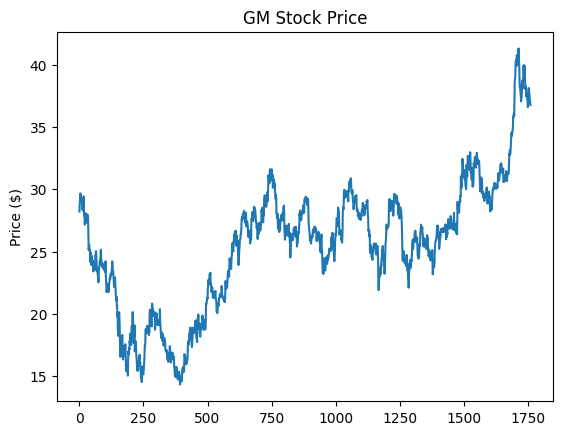

In [16]:
plt.plot(gm.index, gm['Adj Close'])
plt.title('GM Stock Price')
plt.ylabel('Price ($)');
plt.show()


#### visualizamos el precio de la compañia

In [17]:
gm

,Date,Adj Close
0,2011-01-03,28.212450
1,2011-01-04,28.851921
2,2011-01-05,28.981321
3,2011-01-06,29.613180
4,2011-01-07,29.674089
...,...,...
1756,2017-12-22,37.696716
1757,2017-12-26,37.499348
1758,2017-12-27,37.059757
1759,2017-12-28,37.122562


In [18]:
import prophet
# Prophet requiere llamar a la columna "ds" y a la variable a predecir "y"
gm = gm.rename(columns={'Date': 'ds', 'Adj Close': 'y'})


gm_prophet = prophet.Prophet()
#gm_prophet = prophet.Prophet(changepoint_prior_scale=0.15)
gm_prophet.fit(gm)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp826sfbz8/3upm5s4w.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp826sfbz8/k0zlxx2t.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19275', 'data', 'file=/tmp/tmp826sfbz8/3upm5s4w.json', 'init=/tmp/tmp826sfbz8/k0zlxx2t.json', 'output', 'file=/tmp/tmp826sfbz8/prophet_modelbn6t0cyh/prophet_model-20240131024220.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:42:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:42:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [48]:

gm_forecast = gm_prophet.make_future_dataframe(periods=365, freq='D')
# hacemos prediccion
gm_forecast = gm_prophet.predict(gm_forecast)

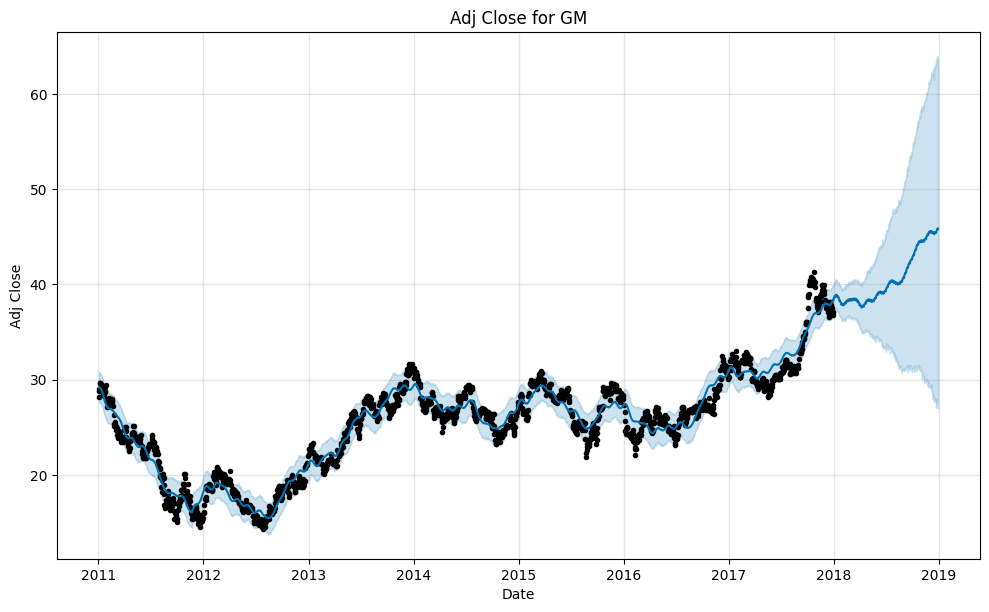

In [49]:
gm_prophet.plot(gm_forecast, xlabel = 'Date', ylabel = 'Adj Close')
plt.title('Adj Close for GM');

In [50]:
gm_forecast = gm_forecast["yhat"].tail(365)

In [51]:
gm_forecast.head(5)

1761    38.306542
1762    38.376786
1763    38.610527
1764    38.654621
1765    38.727322
Name: yhat, dtype: float64

In [45]:
gm_futuro = pd.DataFrame(yf.download(["GM"], start='2018-01-01', end='2021-01-01')['Adj Close']).reset_index()

[*********************100%%**********************]  1 of 1 completed


In [46]:
gm_futuro=gm_futuro["Adj Close"].head(365)

In [47]:
gm_futuro.head(5)

0    37.499344
1    38.414406
2    39.598595
3    39.481964
4    39.670364
Name: Adj Close, dtype: float64

In [41]:
rmse = np.sqrt(mean_squared_error(gm_futuro, gm_forecast))
mae= mean_absolute_error(gm_futuro, gm_forecast)

In [43]:
print(rmse)
print(mae) ### error promedio por 5 dolares

6.784934094023716
5.946163368771482


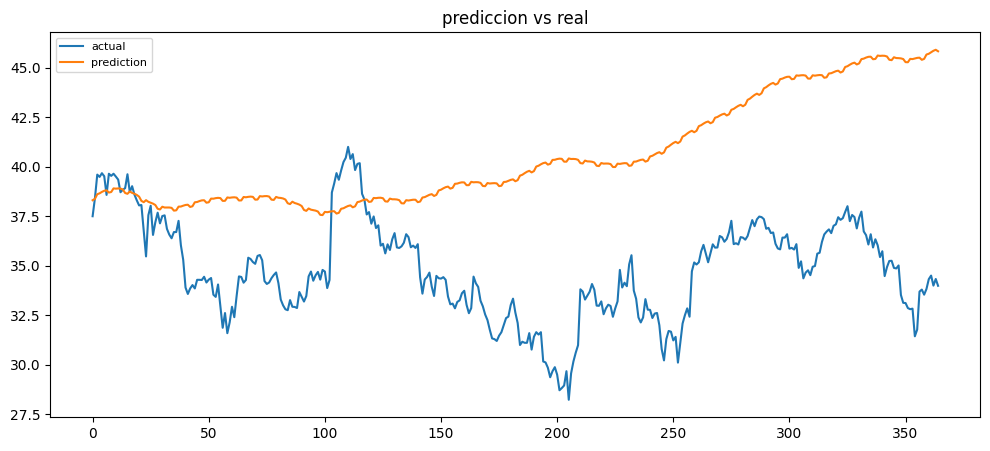

In [53]:
# Plot

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5), dpi=100)
plt.plot(gm_futuro.tolist(), label='actual')
plt.plot(gm_forecast.tolist(), label='prediction')
plt.title('prediccion vs real')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
#### venmos que el pronostico no fue el mejor, aunque la predicción del modelo no se veía mal. 
#### Predecir un año completo puede llevar a sesgar los resultados, aproximadamente en el día 25 se ve que el precio
#### de la accion cae, en este caso pudimos haber reentrenado el modelo en ese punto, observar el pronostico
#### con los valores reales por otro periodo de tiempo y decidir si será necesario entrenar nuevamente el modelo


In [55]:
gm_futuro.tail(5)

360    34.324257
361    34.505363
362    34.000175
363    34.333790
364    33.990643
Name: Adj Close, dtype: float64

In [54]:
gm_forecast.tail(5)

2121    45.695642
2122    45.774184
2123    45.846641
2124    45.896726
2125    45.821361
Name: yhat, dtype: float64